#### Machine Learning Workflow

* Data Import 
Collect and import data, which is a structured set of information used for analysis and learning.

* Data Cleaning & Preparation
Clean the data and apply feature engineering techniques to improve data quality and relevance.

* Data Splitting
Divide the dataset into training and testing sets.
Types of Sampling Techniques in Machine Learning:
Random Sampling: Samples are selected randomly from the dataset.
Stratified Sampling: Maintains the proportion of different classes in both training and testing sets.
K-Fold Cross Validation: The dataset is divided into K subsets, and the model is trained and validated multiple times.
Hold-Out Method: A simple split of data into training and testing sets.

* Model Selection
Choose an appropriate model (acts as the “brain” of the system).

* Model Training
Train the model using the training dataset.

* Prediction
Use the trained model to make predictions on test data.

* Evaluation
Compare actual outputs with predicted results to assess model performance.

* Deployment
Deploy the trained model into a real-world environment for practical use.

# Machine Learning
Machine Learning is a subset of artificial intelligence that enables systems to learn from data and improve their performance without being explicitly programmed.

## Supervised Learning
- The model is trained on **labeled data** (input–output pairs).
- The goal is to learn a mapping from inputs to outputs and make accurate predictions on unseen data.

### Types
**a) Classification**
- Predicts **discrete labels or categories** (e.g., spam vs. not spam).
- 
**b) Regression**
- Predicts **continuous numerical values** (e.g., house prices, temperature).

## Unsupervised Learning
- The model is trained on **unlabeled data**.
- The goal is to identify hidden patterns or structures in the data.

### Main Techniques
**Clustering**
- Groups similar data points together (used in customer segmentation, etc.).
**Dimensionality Reduction**
- Reduces the number of features while preserving important information.
**Association Rule Learning**
- Discovers relationships or patterns between variables (e.g., market basket analysis).

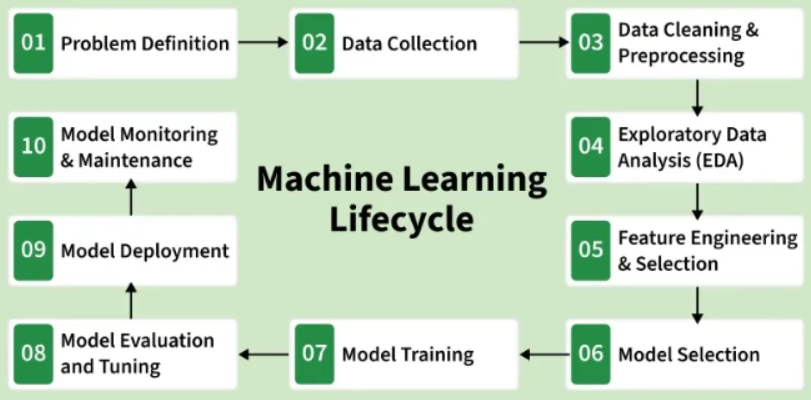

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

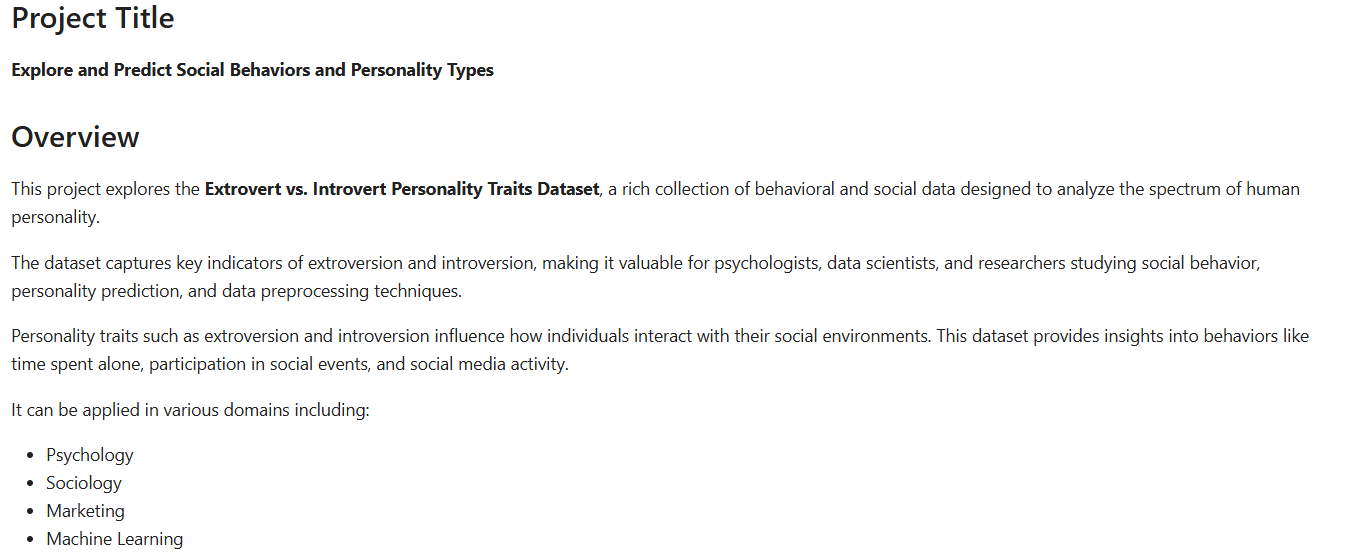
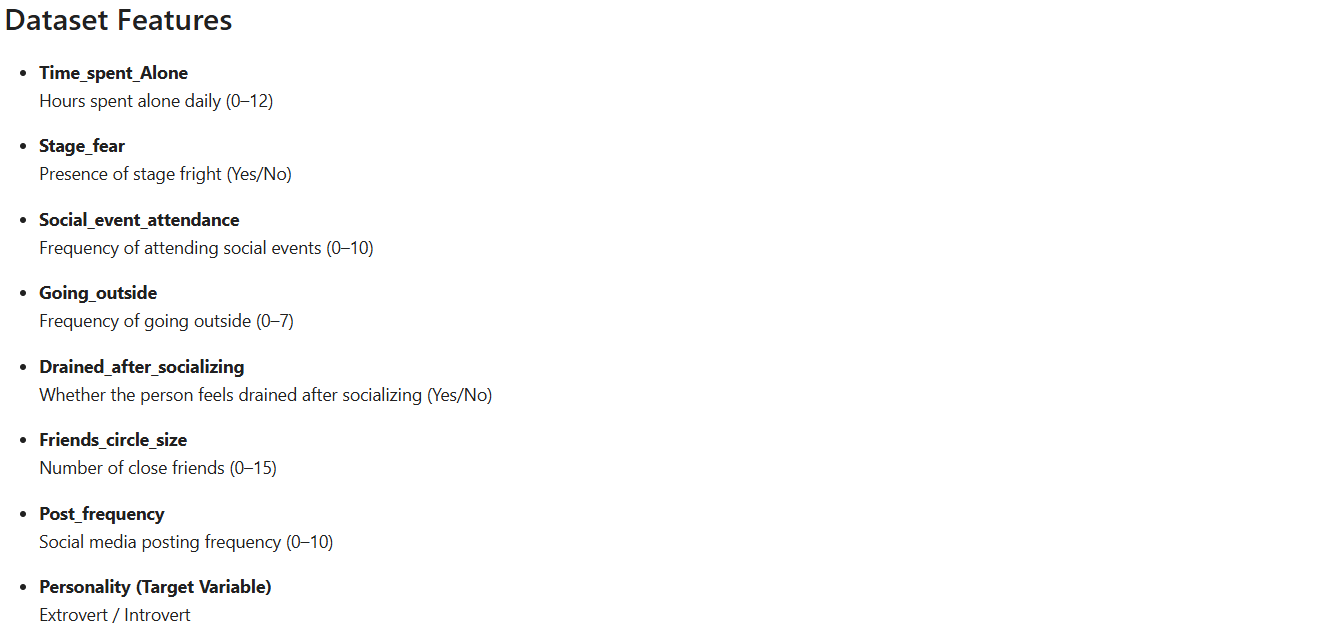

#### 1. Data Import 

In [2]:
df = pd.read_csv("personality_dataset.csv")

In [3]:
df.shape

(2900, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time_spent_Alone,2900.0,4.505816,3.441180,0.0,2.0,4.000000,7.0,11.0
Social_event_attendance,2900.0,3.963354,2.872608,0.0,2.0,3.963354,6.0,10.0
Going_outside,2900.0,3.000000,2.221597,0.0,1.0,3.000000,5.0,7.0
Friends_circle_size,2900.0,6.268863,4.232340,0.0,3.0,5.000000,10.0,15.0
Post_frequency,2900.0,3.564727,2.893587,0.0,1.0,3.000000,6.0,10.0


In [7]:
df.describe(include=['O']).T

,count,unique,top,freq
Stage_fear,2900,2,No,1490
Drained_after_socializing,2900,2,No,1493
Personality,2900,2,Extrovert,1491


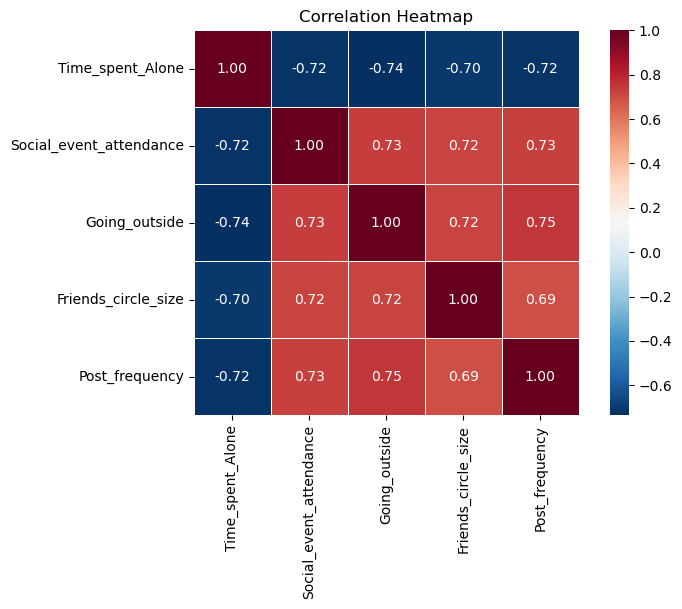

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [10]:
print(df.duplicated().sum())

402


In [11]:
df.drop_duplicates(inplace=True)
df.shape

(2498, 8)

#### 2. Data Cleaning & Preparation 

In [12]:
df['Stage_fear'].value_counts()

Stage_fear
No     1407
Yes    1091
Name: count, dtype: int64

In [13]:
df['Drained_after_socializing'].value_counts()

Drained_after_socializing
No     1409
Yes    1089
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import LabelEncoder
cols_to_encode = ['Stage_fear', 'Drained_after_socializing']
for col in cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,Extrovert
1,9.0,1,0.0,0.0,1,0.0,3.0,Introvert
2,9.0,1,1.0,2.0,1,5.0,2.0,Introvert
3,0.0,0,6.0,7.0,0,14.0,8.0,Extrovert
4,3.0,0,9.0,4.0,0,8.0,5.0,Extrovert


In [15]:
df['Stage_fear'].value_counts()

Stage_fear
0    1407
1    1091
Name: count, dtype: int64

In [16]:
df['Drained_after_socializing'].value_counts()

Drained_after_socializing
0    1409
1    1089
Name: count, dtype: int64

#### 3. Data Splitting
Divide the dataset into training and testing sets.

In [17]:
df.shape

(2498, 8)

In [18]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [19]:
# Input
x = df.loc[:, ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency']]
x.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,4.0,0,4.0,6.0,0,13.0,5.0
1,9.0,1,0.0,0.0,1,0.0,3.0
2,9.0,1,1.0,2.0,1,5.0,2.0
3,0.0,0,6.0,7.0,0,14.0,8.0
4,3.0,0,9.0,4.0,0,8.0,5.0


In [20]:
# Output
y = df.loc[:, ['Personality']]
y.head()

,Personality
0,Extrovert
1,Introvert
2,Introvert
3,Extrovert
4,Extrovert


In [21]:
from sklearn.model_selection import train_test_split
trainx, testx, trainy, testy = train_test_split(x, y, test_size=0.20)

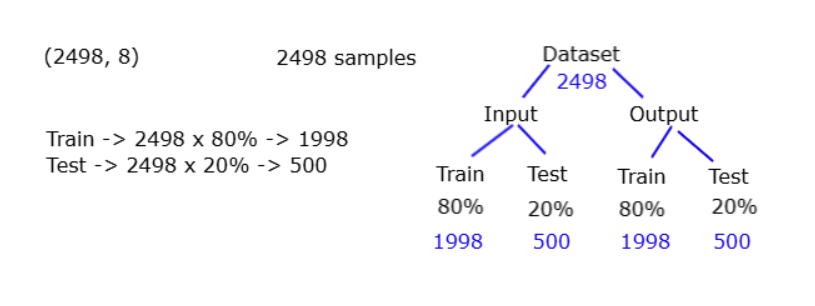

In [22]:
print(df.shape)
print(trainx.shape)
print(testx.shape)
print(trainy.shape)
print(testy.shape)

(2498, 8)
(1998, 7)
(500, 7)
(1998, 1)
(500, 1)


In [23]:
trainx, testx, trainy, testy = train_test_split(x, y, test_size=250)

In [24]:
print(df.shape)
print(trainx.shape)
print(testx.shape)
print(trainy.shape)
print(testy.shape)

(2498, 8)
(2248, 7)
(250, 7)
(2248, 1)
(250, 1)


In [25]:
trainx, testx, trainy, testy = train_test_split(x, y, test_size=250, shuffle=False)

In [26]:
trainx.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,4.0,0,4.0,6.0,0,13.0,5.0
1,9.0,1,0.0,0.0,1,0.0,3.0
2,9.0,1,1.0,2.0,1,5.0,2.0
3,0.0,0,6.0,7.0,0,14.0,8.0
4,3.0,0,9.0,4.0,0,8.0,5.0


In [27]:
testx.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
2566,1.0,0,6.0,3.0,0,11.0,6.0
2567,1.0,0,8.0,4.0,0,14.0,7.0
2568,9.0,1,0.0,1.0,1,5.0,2.0
2569,5.0,1,3.0,0.0,1,2.0,1.0
2570,11.0,1,0.0,2.0,1,3.0,2.0


In [28]:
trainx, testx, trainy, testy = train_test_split(x, y, test_size=250, shuffle=True)

In [29]:
trainx.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
1549,6.0,1,3.0,2.0,1,3.0,0.0
2868,2.0,0,5.0,4.0,0,7.0,8.0
497,10.0,1,2.0,2.0,1,3.0,0.0
2190,5.0,1,1.0,0.0,1,5.0,0.0
1699,4.0,1,1.0,0.0,1,2.0,1.0


In [30]:
testx.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
2238,0.0,0,5.0,5.0,0,6.268863,4.0
2379,2.0,0,9.0,3.0,0,14.000000,7.0
746,2.0,0,4.0,5.0,0,14.000000,9.0
2083,2.0,0,5.0,3.0,0,12.000000,4.0
511,5.0,1,3.0,2.0,1,1.000000,1.0


In [31]:
trainx, testx, trainy, testy = train_test_split(x, y, test_size=250, shuffle=True, random_state = 3)

In [32]:
trainx.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
1139,7.0,1,0.0,2.0,1,5.0,1.0
28,2.0,0,6.0,4.0,0,12.0,10.0
1895,6.0,1,2.0,2.0,0,3.0,1.0
1722,3.0,0,6.0,3.0,0,6.0,5.0
2174,0.0,0,5.0,4.0,0,9.0,4.0


In [33]:
testx.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
605,9.0,1,2.0,2.0,1,0.0,2.0
1380,8.0,1,2.0,1.0,1,5.0,2.0
1857,7.0,1,2.0,1.0,1,4.0,2.0
2739,9.0,1,0.0,2.0,1,4.0,1.0
724,7.0,1,2.0,2.0,1,0.0,0.0


In [34]:
df['Personality'].value_counts(normalize=True)*100

Personality
Extrovert    56.164932
Introvert    43.835068
Name: proportion, dtype: float64

In [35]:
trainy.value_counts(normalize=True)*100

Personality
Extrovert      55.47153
Introvert      44.52847
Name: proportion, dtype: float64

In [36]:
testy.value_counts(normalize=True)*100

Personality
Extrovert      62.4
Introvert      37.6
Name: proportion, dtype: float64

In [37]:
trainx, testx, trainy, testy = train_test_split(x, y, test_size=250, shuffle=True, random_state = 3, stratify=y)

In [38]:
df['Personality'].value_counts(normalize=True)*100

Personality
Extrovert    56.164932
Introvert    43.835068
Name: proportion, dtype: float64

In [39]:
trainy.value_counts(normalize=True)*100

Personality
Extrovert      56.183274
Introvert      43.816726
Name: proportion, dtype: float64

In [40]:
testy.value_counts(normalize=True)*100

Personality
Extrovert      56.0
Introvert      44.0
Name: proportion, dtype: float64

#### 4. Model Selection

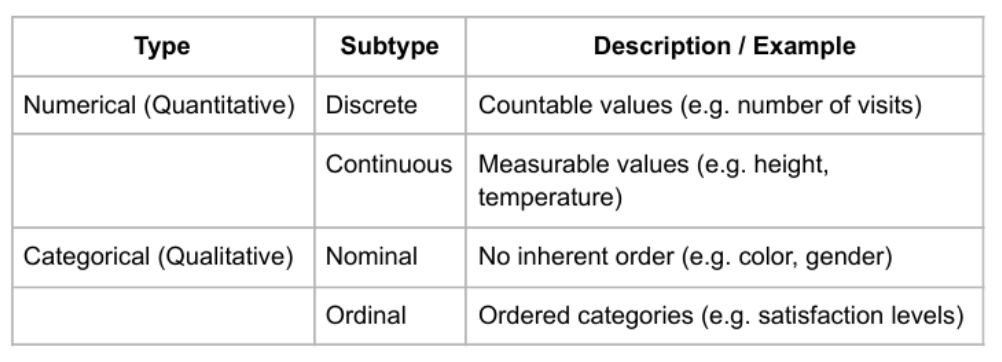

In [41]:
df['Personality'].unique()

array(['Extrovert', 'Introvert'], dtype=object)

Supervised Learning
* model is trained on labelled data(input-output pairs)
* goal is to make a model that predicts the output for unseen data
  * Classification -> predicts dicrete labels or categories
  * Regression -> predicts continuous numeric values

Model 👉 supervised learning - classification

* Logistic Regression
* K-Nearest Neighbors (KNN)
* Support Vector Machine (SVM)
* Decision Tree Classifier
* Random Forest Classifier
* Gradient Boosting Classifier
* XGBoost Classifier
* LightGBM Classifier
* CatBoost Classifier
* Naive Bayes Classifier
* Linear Discriminant Analysis (LDA)
* Quadratic Discriminant Analysis (QDA)
* Neural Network Classifier (MLPClassifier)

In [42]:
from sklearn.tree import DecisionTreeClassifier as DTC

In [43]:
model = DTC(criterion="entropy")

#### 5.Model Training

In [44]:
model.fit(trainx, trainy)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 6.Prediction

In [45]:
predictions = model.predict(testx)
predictions[0:10]

array(['Extrovert', 'Extrovert', 'Extrovert', 'Extrovert', 'Introvert',
       'Introvert', 'Introvert', 'Extrovert', 'Extrovert', 'Extrovert'],
      dtype=object)

#### 7. Evaluation

In [46]:
predictions[0:10]

array(['Extrovert', 'Extrovert', 'Extrovert', 'Extrovert', 'Introvert',
       'Introvert', 'Introvert', 'Extrovert', 'Extrovert', 'Extrovert'],
      dtype=object)

In [47]:
testy.head(10)

,Personality
79,Extrovert
1647,Extrovert
2728,Extrovert
101,Extrovert
1070,Introvert
2400,Introvert
1279,Introvert
2814,Extrovert
1030,Extrovert
1950,Extrovert


In [48]:
print(type(predictions))
print(predictions.shape)

print(type(testy))
print(testy.shape)

<class 'numpy.ndarray'>
(250,)
<class 'pandas.core.frame.DataFrame'>
(250, 1)


In [49]:
testy_array = testy.values.ravel()
accuracy = np.mean(predictions == testy_array)
print("Accuracy:", accuracy * 100)

Accuracy: 87.2


#### 8.Deployment

In [50]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [51]:
df.describe()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
count,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000
mean,4.232128,0.436749,4.200867,3.192954,0.435949,6.580130,3.815283
std,3.406630,0.496083,2.874305,2.218807,0.495980,4.257516,2.914253
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,2.000000,1.000000,0.000000,3.000000,1.000000
50%,3.000000,0.000000,4.000000,3.000000,0.000000,6.000000,3.000000
75%,7.000000,1.000000,7.000000,5.000000,1.000000,10.000000,6.000000
max,11.000000,1.000000,10.000000,7.000000,1.000000,15.000000,10.000000


In [52]:
Time_spent_Alone = int(input('Time spent alone(0-15): '))
Stage_fear = int(input("Do you have stage fear(Yes -> 1/No -> 0):"))
Social_event_attendance = int(input('Social Event Attendance(0-10): '))
Going_outside = int(input('Going_outside(0-10): '))
Drained_after_socializing = int(input("Are you drained after socializing(Yes -> 1/No -> 0):"))
Friends_circle_size = int(input('Friend circle size(0-15): '))
Post_frequency = int(input('Social media posting frquency(0-10): '))

Time spent alone(0-15):  3
Do you have stage fear(Yes -> 1/No -> 0): 1
Social Event Attendance(0-10):  5
Going_outside(0-10):  7
Are you drained after socializing(Yes -> 1/No -> 0): 1
Friend circle size(0-15):  8
Social media posting frquency(0-10):  5


In [53]:
data = pd.DataFrame([[Time_spent_Alone, Stage_fear, Social_event_attendance,
       Going_outside, Drained_after_socializing, Friends_circle_size,
       Post_frequency]], columns = x.columns)
result = model.predict(data)[0]
print(f'You are an {result}')

You are an Introvert


In [54]:
data = pd.DataFrame([[6, 0, 5, 2, 0, 4, 4]], columns=x.columns)
result = model.predict(data)[0]
print(f'You are an {result}')

You are an Extrovert


#### Tree diagram and Feature Importance

In [55]:
x.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency'],
      dtype='object')

In [56]:
model.feature_importances_

array([0.07755789, 0.00178664, 0.06315403, 0.05037957, 0.59292101,
       0.09445203, 0.11974883])

In [57]:
dict(sorted(zip(x.columns, model.feature_importances_),key=lambda item: item[1],reverse=True))

{'Drained_after_socializing': np.float64(0.59292100995675),
 'Post_frequency': np.float64(0.11974883365321143),
 'Friends_circle_size': np.float64(0.09445202523459584),
 'Time_spent_Alone': np.float64(0.07755789031191396),
 'Social_event_attendance': np.float64(0.06315402912138339),
 'Going_outside': np.float64(0.050379573869146065),
 'Stage_fear': np.float64(0.0017866378529993949)}

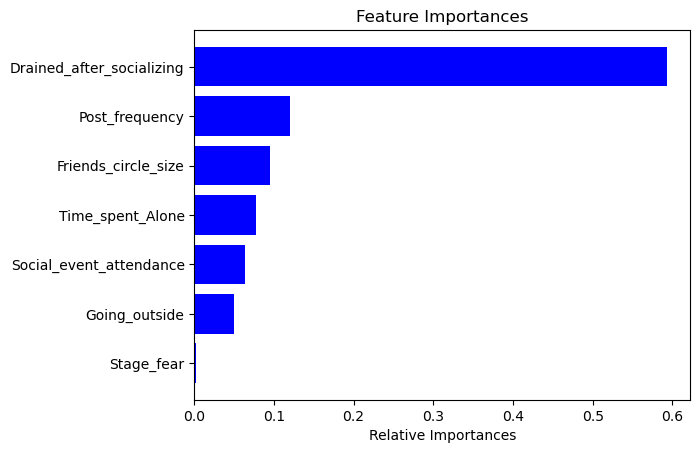

In [58]:
features = x.columns
importances = model.feature_importances_
indices = np.argsort(importances)[-15:]
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importances')
plt.show()

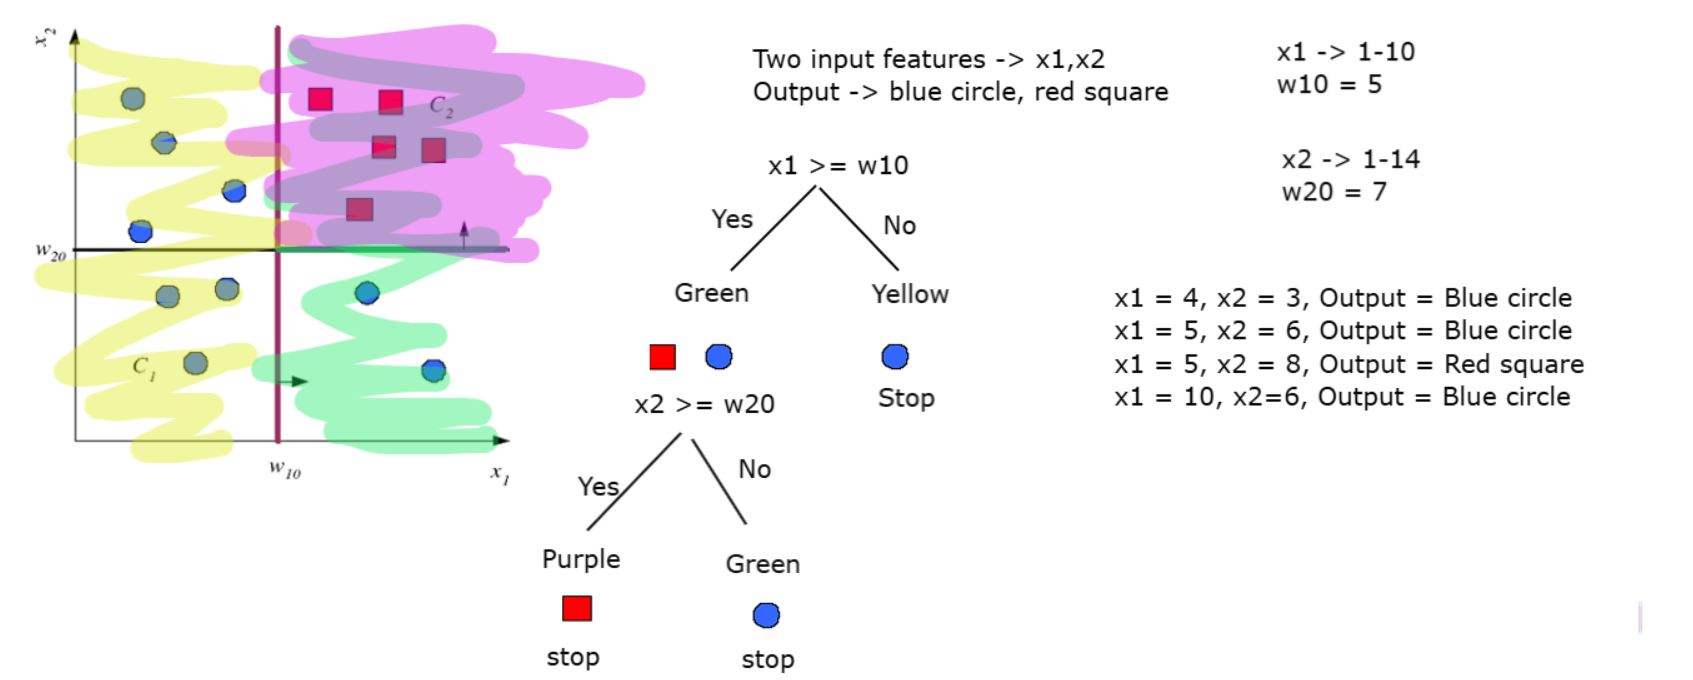

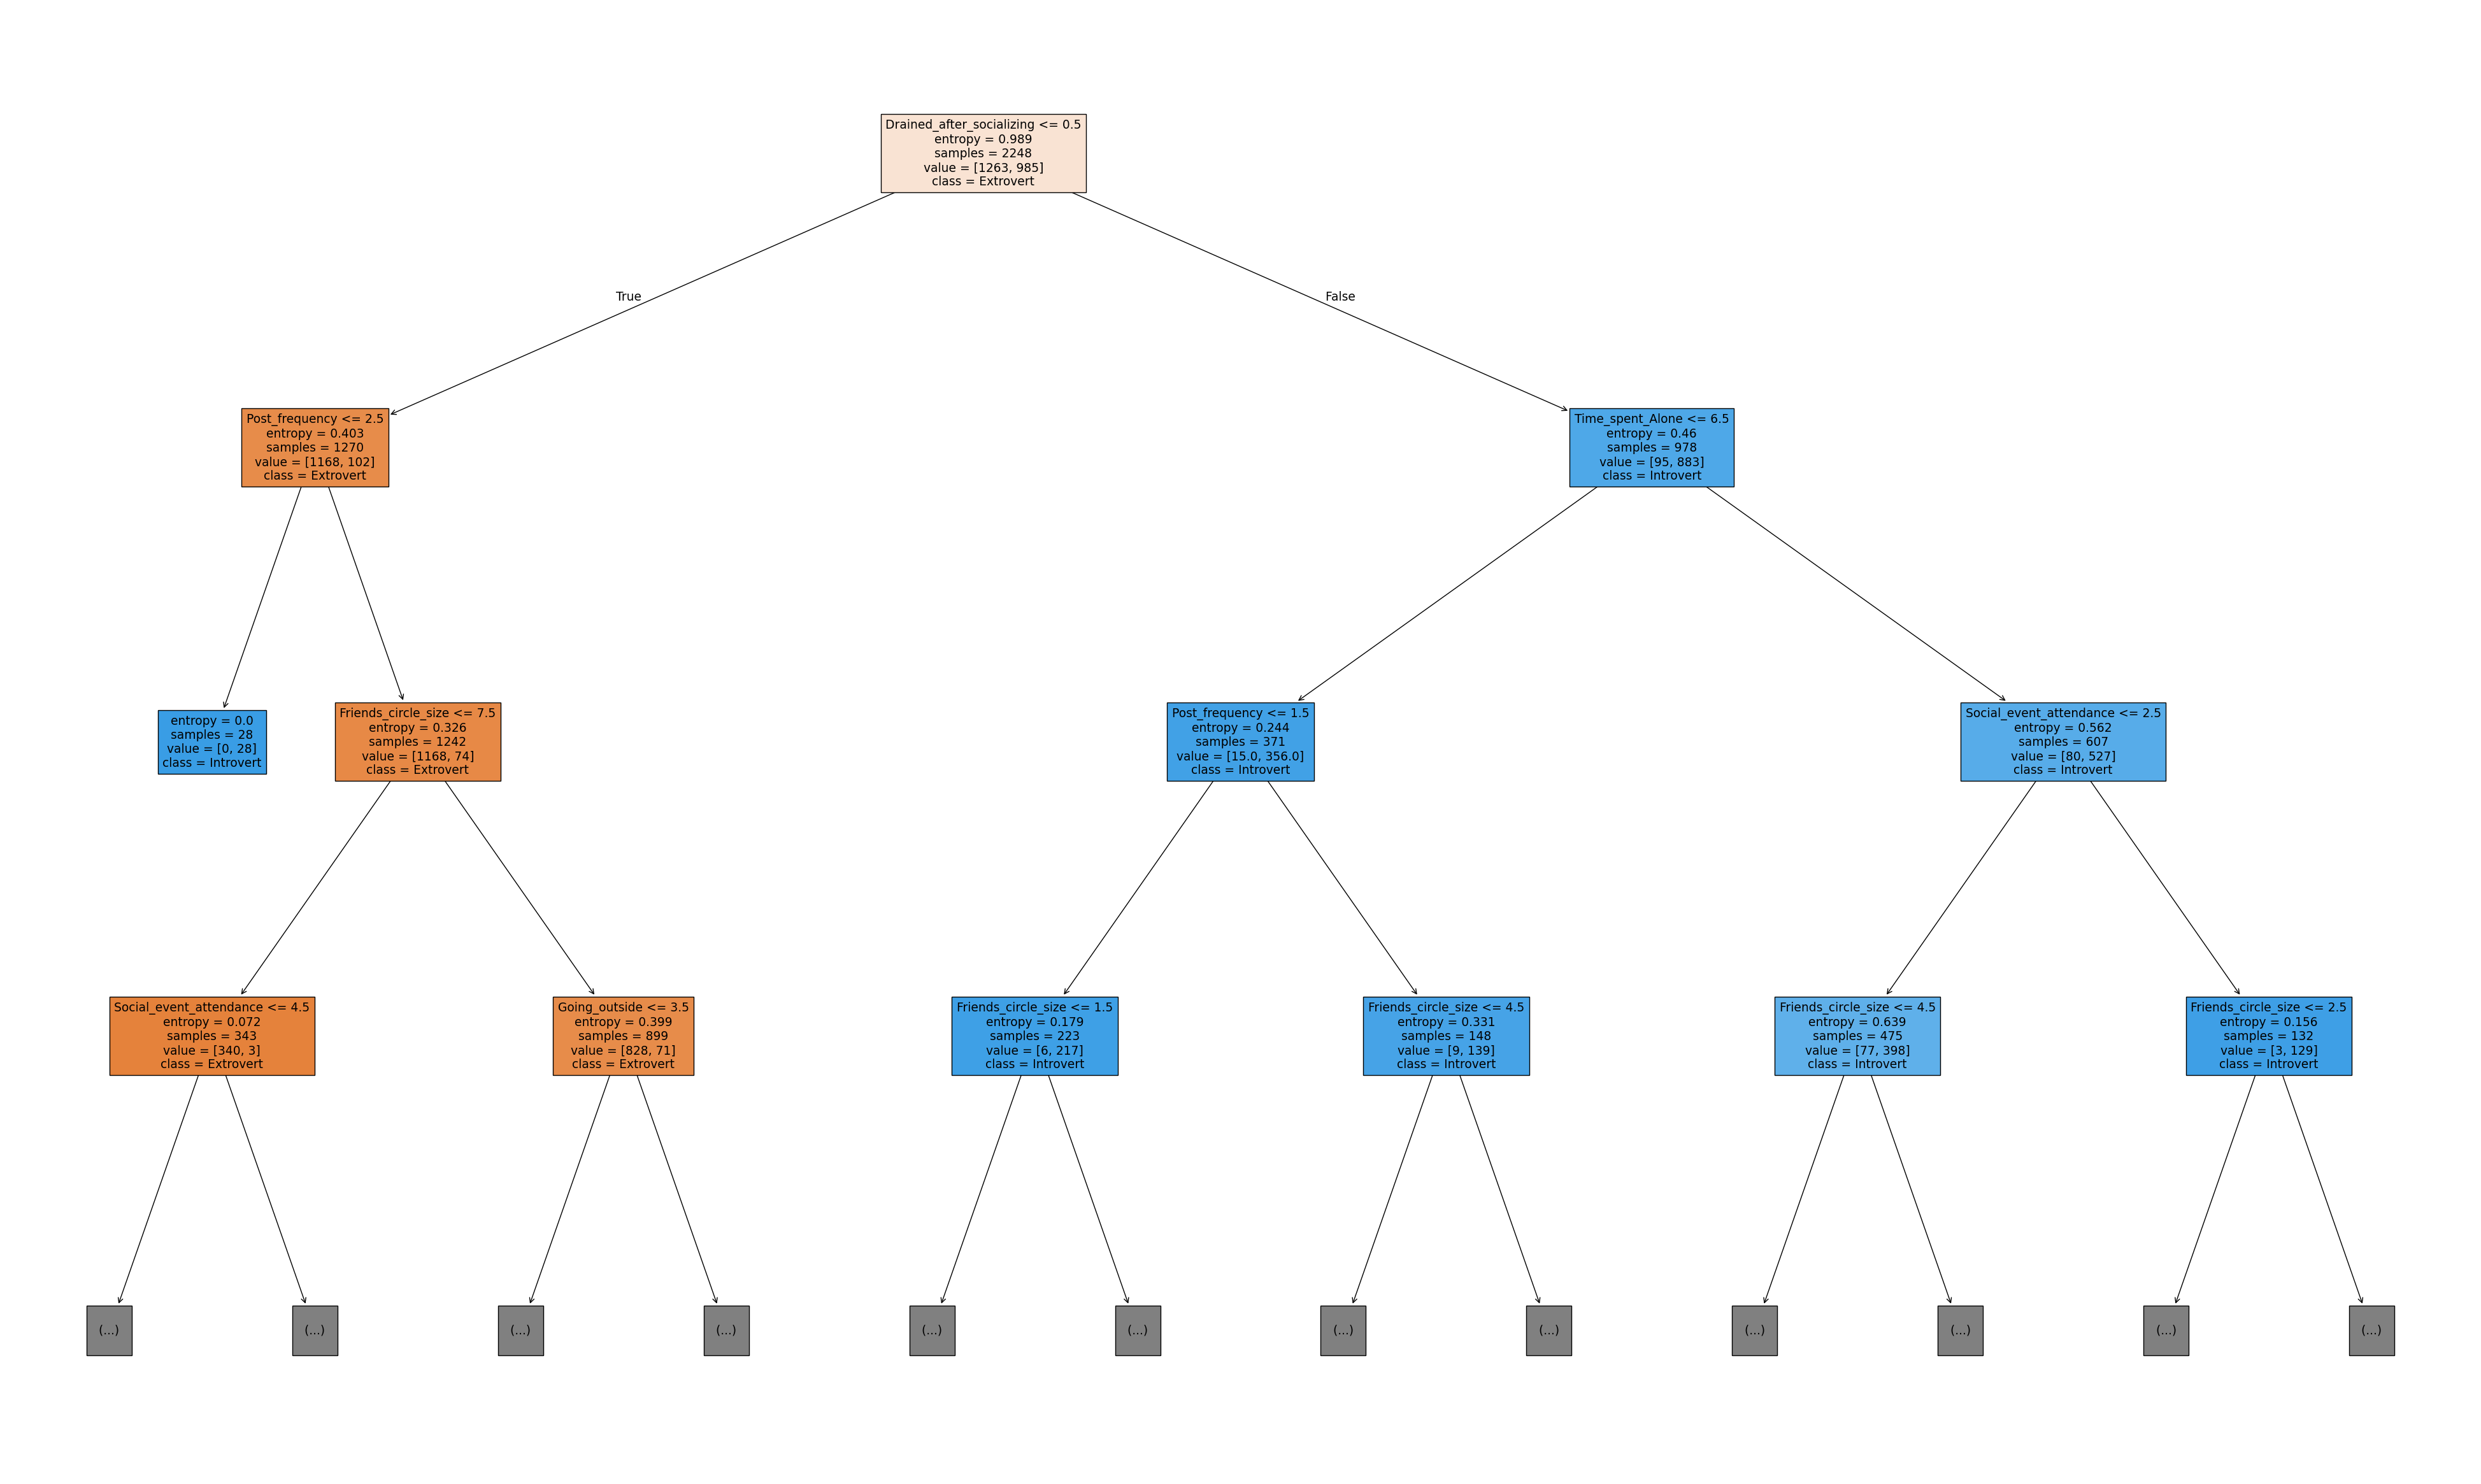

In [59]:
from sklearn import tree
plt.figure(figsize=(50, 30))
tree.plot_tree(
    model,
    max_depth=3,
    feature_names=['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
    class_names=['Extrovert', 'Introvert'],
    label='all',
    filled=True,
    impurity=True,
    node_ids=False,
    proportion=False,
    rounded=False,
    precision=3,
    ax=None,
    fontsize=None,
)
plt.show()

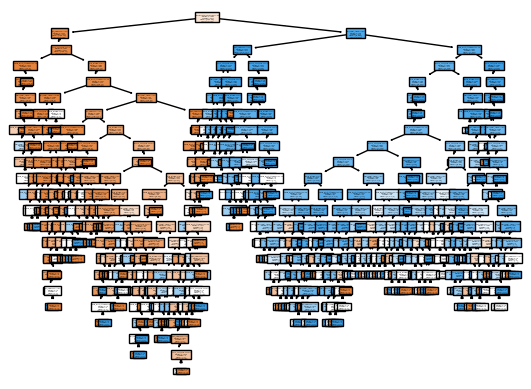

In [60]:
from sklearn import tree
tree.plot_tree(
    model,
    feature_names=['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
    class_names=['Extrovert', 'Introvert'],
    label='all',
    filled=True,
    impurity=True,
    node_ids=False,
    proportion=False,
    rounded=False,
    precision=3,
    ax=None,
    fontsize=None,
)
plt.show()